In [1]:
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import os
import sys
module_path = os.path.abspath(os.path.join('../../../../../'))
if module_path not in sys.path:
    sys.path.append(module_path)
    
from data_science_utilities.models.xgb.hyperparameter_search.random_search import OptimalXGBHyperparameterSearch

In [2]:
RANDOM_SEED = 32
BEST_NUM_FEATS = 34
TARGET = 'target_win'

RANDOM_XGB_PARAMS = {
    # How fast the model learns. The smaller, the more likely to get stuck in local minima, but the larger, the more likely to overshoot the global minima
    'learning_rate': [.03, .05, .1, .15, .2],
    # How deep the tree can be. The deeper, the more likely to overfit and more complex
    'max_depth': [2, 3],
    # The fraction of samples to be used for fitting the individual base learners. 
    # Values lower than 1 make the model more robust by preventing overfitting
    'subsample': [.5, .7, .9],
    # The minimum number of samples required to be at a leaf node. The larger, the more conservative
    'min_child_weight': [10, 20, 50, 100],
    # Minimum loss reduction required to make a split on a leaf node of the tree. Attempts to only split when it makes a significant improvement
    'gamma': [.5, 1, 5, 10, 100],
    # The number of trees to be used in the model. The more, the more likely to overfit
    'n_estimators': [10, 20,30, 40, 50],
    # The number of iterations the model can't improve before stopping
    'early_stopping_rounds': [10, 20, 50],
    # The way the model calculates the importance of each feature. Total gain is the sum of the gain of each feature used in the model
    'importance_type': ['total_gain'],
    # The evaluation metric to be used. AUC measures how well the model is able to distinguish between classes (win or loss)
    'eval_metric': ['auc']
}

RANDOM_SEARCH_PARAMS = dict(
    n_iter=100,
    cv=5,
    n_jobs=-1,
    random_state=RANDOM_SEED,
    scoring='roc_auc',
)

BEST_FEATS_FROM_RFE = list(pd.read_csv(
    '../../../../../data/predict_games/model_features_in/rfe_features_kfolds.csv',
    index_col=0
).loc[BEST_NUM_FEATS, :].dropna().values)

MODEL_INPUTS_DF = pd.read_parquet(
    '../../../../../data/predict_games/input_data/schedule_and_weekly.parquet'
)

MODEL_INPUTS_DF = MODEL_INPUTS_DF.sample(
    frac=1, random_state=RANDOM_SEED
).reset_index(drop=True)

np.random.seed(RANDOM_SEED)

In [3]:
# Train is all games before the 2023 season, holdout is 2023
train_df = MODEL_INPUTS_DF[(MODEL_INPUTS_DF['season'] < 2021)]
test_df = MODEL_INPUTS_DF[
    (MODEL_INPUTS_DF['season'] >= 2021) & (MODEL_INPUTS_DF['season'] < 2023)
]
holdout_df = MODEL_INPUTS_DF[MODEL_INPUTS_DF['season'] == 2023].copy()
X_train = train_df[BEST_FEATS_FROM_RFE]
y_train = train_df[TARGET]
X_test = test_df[BEST_FEATS_FROM_RFE]
y_test = test_df[TARGET]
X_holdout = holdout_df[BEST_FEATS_FROM_RFE]
y_holdout = holdout_df[TARGET]

In [4]:
rand_hyperparam_search = OptimalXGBHyperparameterSearch(
    X_train, y_train, X_test, y_test
)

In [5]:
rand_search = rand_hyperparam_search.search(
    RANDOM_XGB_PARAMS, **RANDOM_SEARCH_PARAMS
)

[0]	validation_0-auc:0.60902	validation_1-auc:0.59587
[1]	validation_0-auc:0.63762	validation_1-auc:0.62964
[2]	validation_0-auc:0.66878	validation_1-auc:0.63162
[3]	validation_0-auc:0.67371	validation_1-auc:0.63415
[4]	validation_0-auc:0.67799	validation_1-auc:0.63582
[5]	validation_0-auc:0.68218	validation_1-auc:0.63896
[6]	validation_0-auc:0.68609	validation_1-auc:0.64286
[7]	validation_0-auc:0.68727	validation_1-auc:0.64243
[8]	validation_0-auc:0.69167	validation_1-auc:0.64100
[9]	validation_0-auc:0.69223	validation_1-auc:0.64314
[10]	validation_0-auc:0.69468	validation_1-auc:0.64075
[11]	validation_0-auc:0.69591	validation_1-auc:0.63718
[12]	validation_0-auc:0.69747	validation_1-auc:0.63791
[13]	validation_0-auc:0.69807	validation_1-auc:0.63716
[14]	validation_0-auc:0.69967	validation_1-auc:0.63644
[15]	validation_0-auc:0.70070	validation_1-auc:0.64010
[16]	validation_0-auc:0.70148	validation_1-auc:0.64188
[17]	validation_0-auc:0.70268	validation_1-auc:0.64100
[18]	validation_0-au

In [6]:
# view all the scores from the search
rand_search.cv_results_

{'mean_fit_time': array([0.81706214, 0.94697895, 0.83145094, 0.82794518, 0.91945977,
        0.33364682, 0.4638833 , 0.46233726, 0.73087697, 0.53860197,
        0.32560182, 0.32554908, 0.77050862, 0.67613301, 0.57451806,
        0.50254164, 0.4502821 , 0.47318368, 0.4678185 , 0.34703412,
        0.35564108, 0.48297262, 0.46870499, 0.71940908, 0.68432298,
        0.79712758, 0.47135406, 0.47668386, 0.63654151, 0.65776491,
        0.59314523, 1.00465274, 0.49734893, 0.82097578, 0.34852262,
        0.3198863 , 0.47598691, 0.61376138, 0.31885233, 0.48583188,
        0.6486917 , 0.718996  , 0.37785153, 0.50125375, 0.79690523,
        0.34887872, 0.32516785, 0.46951075, 0.56949272, 0.59727802,
        0.64907427, 0.33558974, 0.97040601, 0.32384191, 0.67556677,
        0.49003797, 1.03006449, 0.33463621, 0.78125682, 0.42532272,
        0.64151301, 0.60015173, 0.33728676, 0.32316985, 0.51367006,
        0.63133917, 0.41486206, 0.43615675, 0.52044973, 0.92408743,
        0.52377791, 0.48022285,

<Axes: >

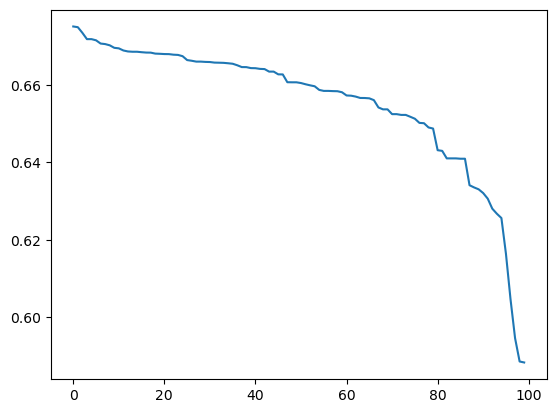

In [7]:
# Graph the search results. Make the index the rank of the score
# another column for the mean test score
rand_search_results = pd.DataFrame(rand_search.cv_results_)
rand_search_results['rank_test_score'] = rand_search_results['rank_test_score']
rand_search_results['mean_test_score'] = rand_search_results['mean_test_score']
rand_search_results = rand_search_results.sort_values(by='rank_test_score', ascending=True)
rand_search_results = rand_search_results.reset_index(drop=True)
rand_search_results['mean_test_score'].plot()

In [8]:
# What are the grid search params for the top 5 scores?
rand_search_results.head(5)

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_subsample,param_n_estimators,param_min_child_weight,param_max_depth,param_learning_rate,param_importance_type,...,param_early_stopping_rounds,params,split0_test_score,split1_test_score,split2_test_score,split3_test_score,split4_test_score,mean_test_score,std_test_score,rank_test_score
0,0.736360,0.099874,0.014425,0.001175,0.9,50,50,2,0.2,total_gain,...,20,"{'subsample': 0.9, 'n_estimators': 50, 'min_ch...",0.691003,0.689021,0.666588,0.645499,0.683052,0.675033,0.017080,1
1,0.919460,0.027299,0.015647,0.002058,0.7,50,100,2,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.692294,0.691892,0.666979,0.645292,0.677786,0.674848,0.017544,2
2,0.484672,0.017628,0.014938,0.001243,0.9,20,50,2,0.2,total_gain,...,50,"{'subsample': 0.9, 'n_estimators': 20, 'min_ch...",0.682816,0.689021,0.666588,0.645499,0.683052,0.673395,0.015816,3
3,0.827945,0.048528,0.013077,0.000932,0.7,40,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 40, 'min_ch...",0.683242,0.677855,0.671844,0.639824,0.686071,0.671767,0.016696,4
4,1.004653,0.045526,0.016141,0.004539,0.7,50,20,3,0.1,total_gain,...,50,"{'subsample': 0.7, 'n_estimators': 50, 'min_ch...",0.683242,0.677855,0.671844,0.639824,0.686071,0.671767,0.016696,4


In [9]:
# save the json of the best model
best_model = rand_search.best_estimator_
best_model.save_model(
    os.path.join(module_path, 'models', 'best_random_xgb_model.json')
)

In [10]:
# What is the score on the holdout set?
best_model.score(X_holdout, y_holdout)

0.5974264705882353

In [11]:
holdout_df.loc[:, 'preds'] = best_model.predict_proba(X_holdout)[:, 1]

In [12]:
# Show the predictions for the holdout set
results_df = holdout_df[
    ['game_id', 'week', 'target_team', 'opp_team', 'target_win', 'preds']
].copy()
results_df.sort_values(by='game_id', inplace=True)
results_df.reset_index(drop=True, inplace=True)
results_df

,game_id,week,target_team,opp_team,target_win,preds
0,2023_01_ARI_WAS,1,WAS,ARI,1,0.523221
1,2023_01_ARI_WAS,1,ARI,WAS,0,0.504912
2,2023_01_BUF_NYJ,1,BUF,NYJ,0,0.585742
3,2023_01_BUF_NYJ,1,NYJ,BUF,1,0.423873
4,2023_01_CAR_ATL,1,CAR,ATL,0,0.421575
...,...,...,...,...,...,...
539,2023_18_PIT_BAL,18,BAL,PIT,0,0.647961
540,2023_18_SEA_ARI,18,ARI,SEA,0,0.426724
541,2023_18_SEA_ARI,18,SEA,ARI,1,0.574823
542,2023_18_TB_CAR,18,CAR,TB,0,0.387548


week
1     0.628906
2     0.515625
3     0.535156
4     0.878906
5     0.410714
6     0.693333
7     0.337278
8     0.689453
9     0.852041
10    0.612245
11    0.887755
12    0.546875
13    0.792899
14    0.480000
15    0.818359
16    0.544922
17    0.751953
18    0.601562
dtype: float64

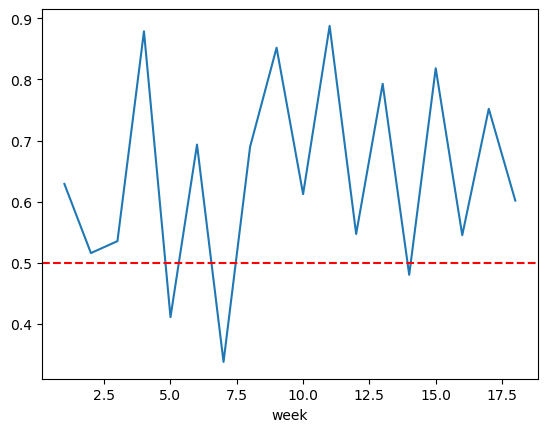

In [13]:
# get the AUROC score by week
weekly_scores = holdout_df.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores

In [14]:
# for each game_id, only keep the higher prediction
higher_preds = holdout_df.groupby('game_id').apply(
    lambda x: x.loc[x['preds'].idxmax(), :],
    include_groups=False
)
higher_preds.reset_index(drop=True, inplace=True)

week
1     0.508333
2     0.546875
3     0.562500
4     0.875000
5     0.458333
6     0.740741
7     0.450000
8     0.527273
9     0.666667
10    0.422222
11    1.000000
12    0.609375
13    0.363636
14    0.607143
15    0.754545
16    0.578125
17    0.681818
18    0.533333
dtype: float64

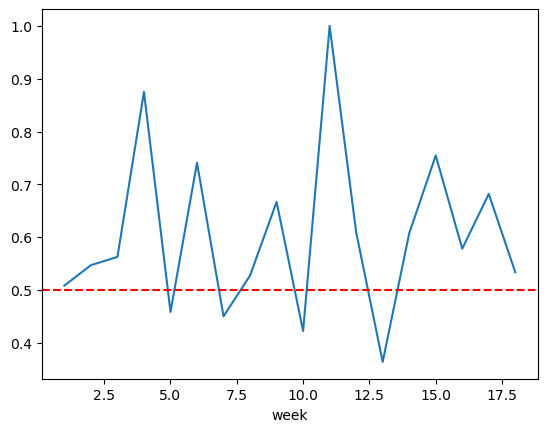

In [15]:
# get the AUROC score by week
weekly_scores = higher_preds.groupby('week').apply(
    lambda x: roc_auc_score(x['target_win'], x['preds']),
    include_groups=False
)
weekly_scores.plot()
# Place a horizontal line at .5 to show the baseline
plt.axhline(y=.5, color='r', linestyle='--')
weekly_scores